In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from rich import print

import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [5]:
forcing_path_ERA5 = Path.home() / "BEP-beau/BEP/code" / "CatchmentArea" / "ERA5_1" / "own_shapefile_1"
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)
data = pd.read_csv("mohembo_daily_water_discharge_data.csv", index_col='date', parse_dates=True, dayfirst=True)

In [15]:
Area_km2 = 173696.852

def mmday_to_m3s(Q_sim_mmday, area_km2):
    return (Q_sim_mmday * area_km2) / 86.4

In [4]:
print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1975-01-01T00:00:00Z',
    end_time='2020-12-31T00:00:00Z',
    directory=PosixPath('/home/beau/BEP-beau/BEP/code/ShapefileMohembo/ERA5/own_shapefile/work/diagnostic/script'),
    shape=PosixPath('/home/beau/BEP-beau/BEP/code/ShapefileMohembo/ERA5/own_shapefile/work/diagnostic/script/UpperC
atchmentAreaMohembo.shp'),
    filenames={
        'pr': 'OBS6_ERA5_reanaly_1_day_pr_1975-2020.nc',
        'tas': 'OBS6_ERA5_reanaly_1_day_tas_1975-2020.nc',
        'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1975-2020.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

In [27]:
par_0 = [1.15381635e+00, 1.44109292e+00, 1.09051138e+03, 1.52100392e+00,
       2.11993707e-01, 8.08588873e+01, 8.81657547e-03, 5.98875895e-04,
       3.90705067e-01]

param_names = ["Imax",
               "Ce",
               "Sumax",
               "Beta",
               "Pmax",
               "Tlag",
               "Kf",
               "Ks",
               "FM"
               ]

print(list(zip(param_names, par_0)))

[
    ('Imax', 1.15381635),
    ('Ce', 1.44109292),
    ('Sumax', 1090.51138),
    ('Beta', 1.52100392),
    ('Pmax', 0.211993707),
    ('Tlag', 80.8588873),
    ('Kf', 0.00881657547),
    ('Ks', 0.000598875895),
    ('FM', 0.390705067)
]

In [28]:
s_0 = np.array([0,  100,  0,  5,  0])

In [29]:
model = ewatercycle.models.HBV(forcing=ERA5_forcing)

In [30]:
config_file, _ = model.setup(parameters=par_0, initial_storage=s_0)

In [31]:
model.initialize(config_file)

In [32]:
Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

In [33]:
model.finalize()

In [34]:
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

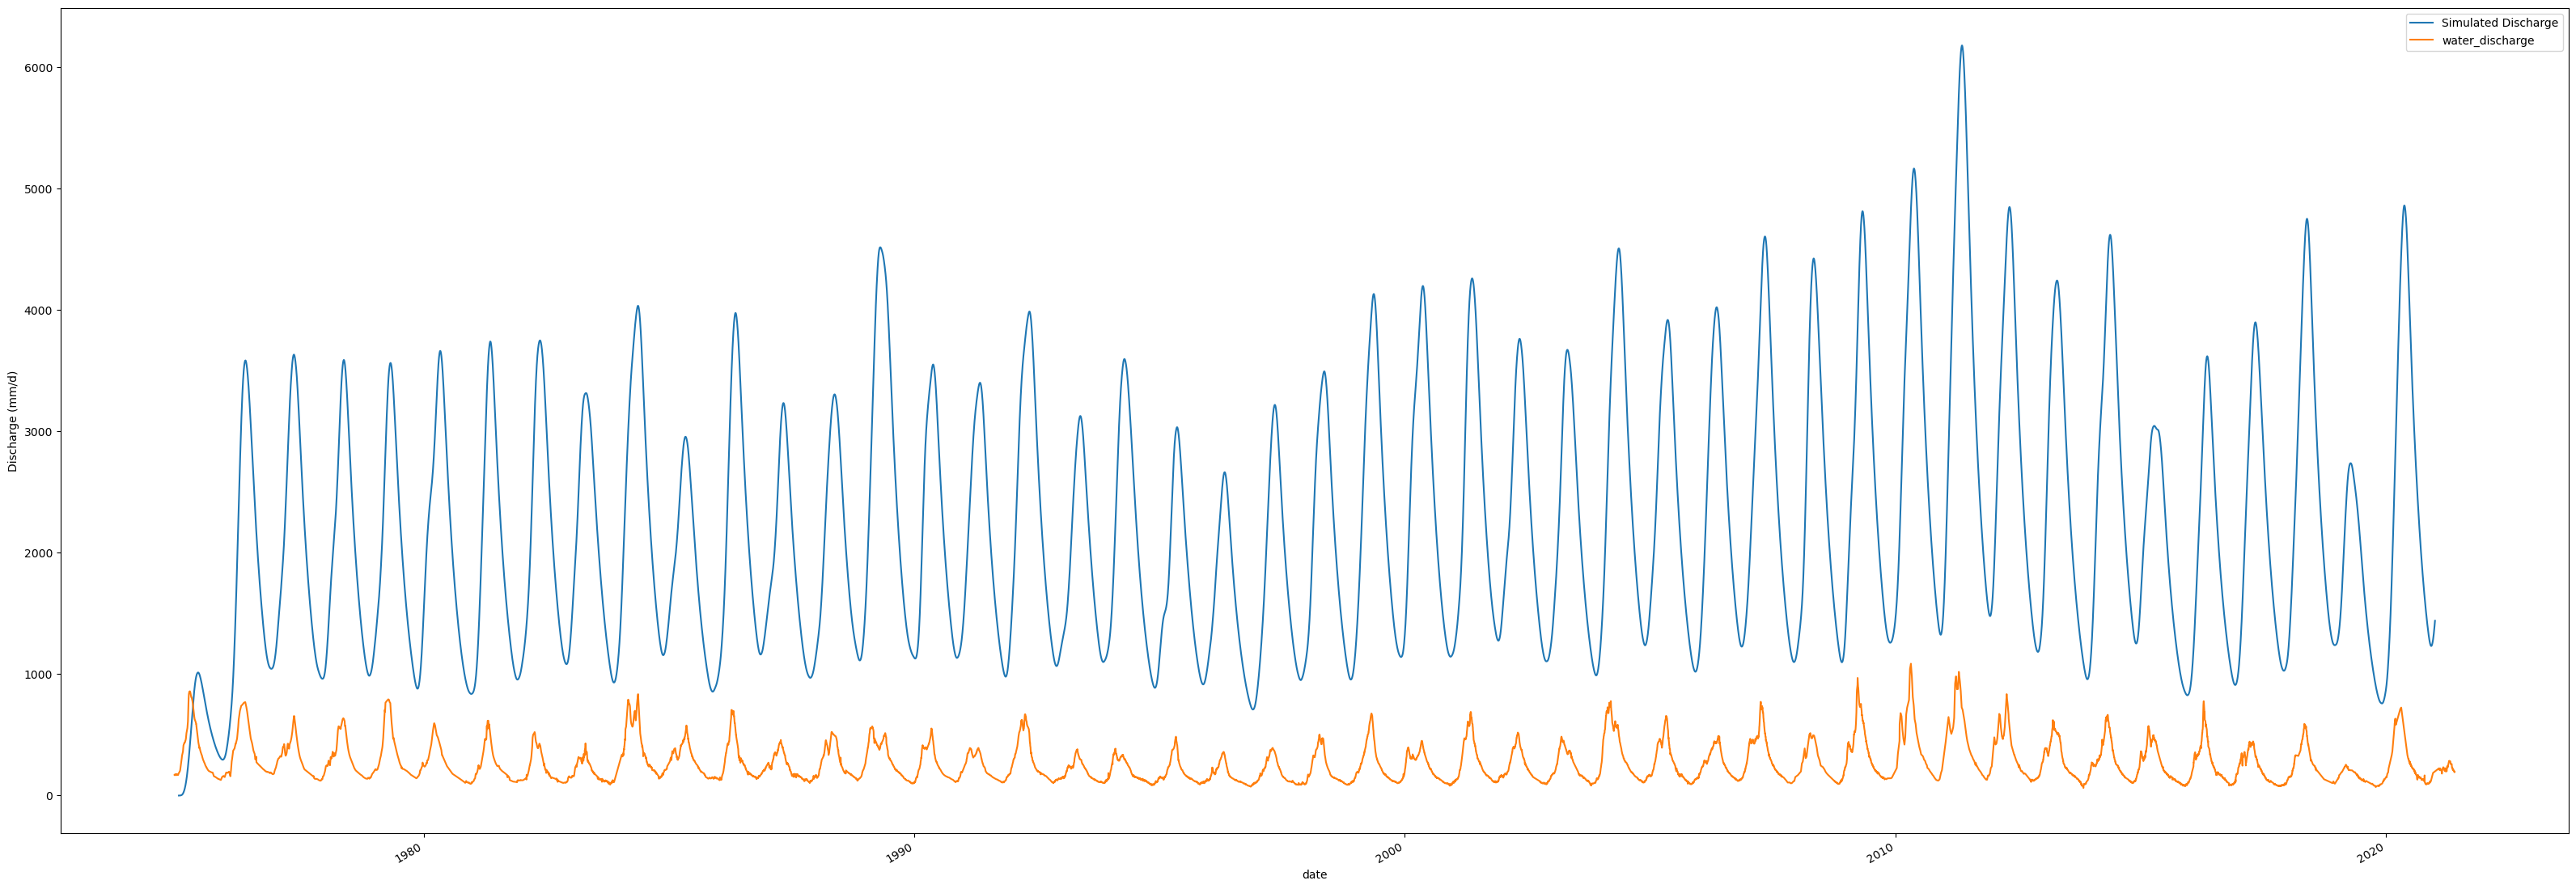

In [35]:
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="Simulated Discharge")

fig, ax = plt.subplots(figsize=(40, 15))
Q_model_pd.plot(ax=ax)
data.plot(ax=ax)
plt.legend()
plt.ylabel("Discharge (mm/d)");